# Artresearch: Environmental Risk vs. the Digitization of Archaeological Sites

* **Course:** Information Visualization
* **Author:** Vesci Cecilia
* **Year:** 2025-2026


### Abstract

This project explores the relationship between environmental risk and the preservation of the digital record of approximately 1,000 Italian archaeological sites, integrating Linked Open Data and geospatial data streams. The initial dataset, including geographic coordinates and metadata, was extracted from Wikidata. To define territorial vulnerability, official institutional sources were used: flood hazard polygons were derived from Shapefiles provided by ISPRA (Higher Institute for Environmental Protection and Research), while seismic risk classifications were obtained from open data provided by INGV (National Institute of Geophysics and Volcanology). Using spatial join operations, this environmental data was cross-referenced with the sites’ coordinates to determine their risk level. Finally, the digitization status of the works was verified by querying the ArtResearch.net knowledge graph, applying a text-matching and geographic validation algorithm to ensure the exclusion of false positives.


### Data Sources

* **Wikidata**
* **ISPRA (Istituto Superiore per la Protezione e la Ricerca Ambientale)** 
* **INGV (Istituto Nazionale di Geofisica e Vulcanologia)** 
* **ArtResearch.net** 

### Reasearch Question
* **RQ1:** What is the current status of the digital documentation on Artresearch regarding Italian archaeological sites facing environmental challenges? 
* **RQ2:** Is there a correlation between the physical vulnerability of the territory and the priority given to digitizing cultural heritage to preserve its memory?


### Workflow: Data Extraction and Spatial Analysis (ISPRA and INGV)
The project begins by extracting data on approximately 1,000 Italian archaeological sites and their geographic coordinates by querying the Wikidata endpoint. Subsequently, the precise coordinates of the archaeological sites were computationally cross-referenced with the risk polygons from ISPRA (for hydrogeological hazard) and INGV (for seismic hazard) using spatial join operations (using geospatial libraries such as GeoPandas). This process made it possible to assign each site an objective risk level (Low, Medium, High) for both hazards, saving and organizing all the information in a CSV file.


In [48]:
import pandas as pd
from SPARQLWrapper import SPARQLWrapper, JSON

endpoint_url = "https://query.wikidata.org/sparql"
sparql = SPARQLWrapper(endpoint_url)

query = """
SELECT DISTINCT ?site ?siteLabel ?lat ?lon ?geonamesID 
WHERE {
  ?site wdt:P31 wd:Q839954 .
  ?site wdt:P17 wd:Q38 .
OPTIONAL {?site wdt:P1566 ?geonamesID .}
  ?site p:P625 ?coordinate .
  ?coordinate psv:P625 ?coordinate_node .
  ?coordinate_node wikibase:geoLatitude ?lat .
  ?coordinate_node wikibase:geoLongitude ?lon .
  
  SERVICE wikibase:label { bd:serviceParam wikibase:language "it,en". }
}
LIMIT 1000
"""

sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

data = []
for result in results["results"]["bindings"]:
    data.append({
        "site_uri": result["site"]["value"],
        "site_name": result["siteLabel"]["value"],
        "latitude": float(result["lat"]["value"]),
        "longitude": float(result["lon"]["value"]),
        "geonames_id": result.get("geonamesID", {}).get("value", None)
    })

df_siti = pd.DataFrame(data)
df_siti = df_siti.drop_duplicates(subset='site_uri')

display(df_siti.head())

df_siti.to_csv("siti_archeologici_italia_en.csv", index=False)
print(f"Scaricati {len(df_siti)} siti")

,site_uri,site_name,latitude,longitude,geonames_id
0,http://www.wikidata.org/entity/Q1439180,Forum Clodii,42.129370,12.164450,None
1,http://www.wikidata.org/entity/Q1523625,tomba dei giganti San Cosimo,39.506030,8.616286,None
2,http://www.wikidata.org/entity/Q1722122,Calacte,38.024241,14.440957,None
3,http://www.wikidata.org/entity/Q1523629,tomba dei giganti di Su Mont'e s'Abe,40.875667,9.484028,None
4,http://www.wikidata.org/entity/Q1485807,Grotta del Genovese,38.003100,12.322200,None


Scaricati 880 siti


In [49]:
import pandas as pd
import geopandas as gpd

df_siti = pd.read_csv("siti_archeologici_italia_en.csv")
gdf_siti = gpd.GeoDataFrame(df_siti, geometry=gpd.points_from_xy(df_siti.longitude, df_siti.latitude), crs="EPSG:4326")

gdf_alluvione_alta = gpd.read_file("dati_rischio/HPH_Mosaicatura_ISPRA_2020_pericolosita_idraulica_elevata.shp").to_crs("EPSG:4326")
gdf_alluvione_media = gpd.read_file("dati_rischio/MPH_Mosaicatura_ISPRA_2020_pericolosita_idraulica_media.shp").to_crs("EPSG:4326")
gdf_alluvione_bassa = gpd.read_file("dati_rischio/LPH_Mosaicatura_ISPRA_2020_pericolosita_idraulica_bassa.shp").to_crs("EPSG:4326")
df_sismico = pd.read_excel("dati_rischio/ag_02percento.xls")
gdf_sismico = gpd.GeoDataFrame(df_sismico, geometry=gpd.points_from_xy(df_sismico.Lon, df_sismico.Lat), crs="EPSG:4326")

gdf_siti['Rischio_Alluvione'] = 'Basso'
siti_in_media = gpd.sjoin(gdf_siti, gdf_alluvione_media, how="inner", predicate="intersects")
gdf_siti.loc[gdf_siti.index.isin(siti_in_media.index), 'Rischio_Alluvione'] = 'Medio'
siti_in_alta = gpd.sjoin(gdf_siti, gdf_alluvione_alta, how="inner", predicate="intersects")
gdf_siti.loc[gdf_siti.index.isin(siti_in_alta.index), 'Rischio_Alluvione'] = 'Elevato'

gdf_siti_proj = gdf_siti.to_crs("EPSG:32632")
gdf_sismico_proj = gdf_sismico.to_crs("EPSG:32632")
risultato = gpd.sjoin_nearest(gdf_siti_proj, gdf_sismico_proj, how="left", distance_col="dist")

def classifica_sisma(ag):
    if ag > 0.25: return 'Elevato'
    if ag > 0.15: return 'Medio'
    return 'Basso'

risultato['Rischio_Terremoto'] = risultato['ag'].apply(classifica_sisma)

gdf_finale = risultato[['site_name', 'geonames_id', 'latitude', 'longitude','Rischio_Alluvione', 'Rischio_Terremoto']].copy()
display(gdf_finale.head(10))
gdf_finale.to_csv("siti_analisi_finale.csv", index=False)

,site_name,geonames_id,latitude,longitude,Rischio_Alluvione,Rischio_Terremoto
0,Forum Clodii,NaN,42.129370,12.164450,Basso,Basso
1,tomba dei giganti San Cosimo,NaN,39.506030,8.616286,Basso,Basso
2,Calacte,NaN,38.024241,14.440957,Basso,Elevato
3,tomba dei giganti di Su Mont'e s'Abe,NaN,40.875667,9.484028,Basso,Basso
4,Grotta del Genovese,NaN,38.003100,12.322200,Basso,Basso
5,Scale Gemonie,NaN,41.893333,12.484722,Basso,Medio
6,Lorium,3179707.0,41.901109,12.285650,Basso,Basso
7,tomba dei giganti di Pedras Doladas,NaN,40.216328,8.613968,Basso,Basso
8,Pyrgi,NaN,42.015226,11.963414,Basso,Basso
9,Mausoleo di Elena,NaN,41.878900,12.548810,Basso,Medio


### Workflow: Querying ArtResearch and Geographic Validation
The next phase involved merging the geographic data with ArtResearch’s Linked Open Data. Since ArtResearch does not have a native geographic filter for Italy (unlike Wikidata), it was necessary to download a global list of sites from the platform and filter it. The first filter was applied by comparing the names of the sites, which proved to be the only effective way to obtain accurate results.
To avoid ambiguity, the results were further verified by matching geographic coordinates.

In [50]:

import pandas as pd
from SPARQLWrapper import SPARQLWrapper, JSON

endpoint = "https://artresearch.net/sparql"
sparql = SPARQLWrapper(endpoint)
sparql.agent = "InfoVizProject/1.0 (progetto universitario)"

query = """
PREFIX crm: <http://www.cidoc-crm.org/cidoc-crm/>
PREFIX custom: <https://artresearch.net/custom/>

SELECT ?work ?name
WHERE {
  ?work crm:P2_has_type <https://artresearch.net/resource/pharos/vocab/meta/built_work> ;
        custom:has_image true ;
        crm:P1_is_identified_by ?appellation .
  ?appellation crm:P2_has_type <https://artresearch.net/resource/pharos/vocab/meta/pharos_preferred_name> ;
               crm:P190_has_symbolic_content ?name .
}
"""

sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()["results"]["bindings"]

documented_works = pd.DataFrame([
    {"work_uri": r["work"]["value"], "name": r["name"]["value"]}
    for r in results
])

print(f"Opere architettoniche documentate con foto trovate su ArtResearch: {len(documented_works)}")
documented_works.to_csv("artresearch_built_works_con_immagine.csv", index=False)

Opere architettoniche documentate con foto trovate su ArtResearch: 46490


In [51]:
import pandas as pd

sites_df = pd.read_csv("siti_analisi_finale.csv")
documented_works = pd.read_csv("artresearch_built_works_con_immagine.csv")

def trova_match_identico(nome_sito, df_artresearch):
    if not isinstance(nome_sito, str):
        return None, 0, None

    
    nome_sito_pulito = nome_sito.lower().strip()

    for index, row in df_artresearch.iterrows():
        nome_art = str(row['name'])
        
        nome_art_senza_citta = nome_art.split(',')[0].lower().strip()
        

        if nome_sito_pulito == nome_art_senza_citta:
            
           
            if "," in nome_art:
                citta_estratta = nome_art.split(",")[-1].strip()
            else:
                citta_estratta = nome_art.strip()
                
            return nome_art, 100, citta_estratta
                
    return None, 0, None

risultati = sites_df['site_name'].apply(lambda x: trova_match_identico(x, documented_works))

sites_df['artresearch_match'] = [res[0] for res in risultati]
sites_df['match_score'] = [res[1] for res in risultati]
sites_df['match_place'] = [res[2] for res in risultati]

sites_df['documentato'] = sites_df['match_score'] == 100

match_trovati = sites_df['documentato'].sum()
print(f"Trovati {match_trovati} match ESATTI.")

Trovati 82 match ESATTI.


In [54]:

from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time

geolocator = Nominatim(user_agent="Progetto_InfoViz_Unibo_Arte_v2")

cache_citta = {}

def valida_match_geografico(row):

    if not row['documentato']:
        return False
        
    citta_art = row['match_place']
    lat_wiki = row['latitude']
    lon_wiki = row['longitude']
    
    
    if pd.isna(citta_art) or pd.isna(lat_wiki):
        return False
        

    if citta_art not in cache_citta:
        try:
            loc = geolocator.geocode(f"{citta_art}, Italia", timeout=10)
            cache_citta[citta_art] = (loc.latitude, loc.longitude) if loc else None
            time.sleep(1)
        except:
            cache_citta[citta_art] = None
            
    coords_citta = cache_citta[citta_art]
    
   
    if not coords_citta:
        return False
        
    
    distanza_km = geodesic((lat_wiki, lon_wiki), coords_citta).kilometers
    

    return distanza_km < 50

sites_df['documentato_realmente'] = sites_df.apply(valida_match_geografico, axis=1)

totale_reali = sites_df['documentato_realmente'].sum()

sites_df.to_csv("siti_con_rischio_e_digitalizzazione_CERTIFICATI.csv", index=False)


### Results and Exploratory Data Analysis (EDA)

Using the consolidated dataset, the tabular data were processed to calculate the percentages of archaeological sites digitized on ArtResearch based on different territorial risk levels (Low, Medium, High). These data were visualized using Seaborn in two side-by-side bar charts, allowing for an immediate comparison of the distribution of digitization percentages across the risk categories.

/var/folders/mg/n7t96bds11q12nsff6w2qvjh0000gn/T/ipykernel_93552/2792322329.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dati_alluvione, x='Rischio_Alluvione', y='Percentuale (%)',
/var/folders/mg/n7t96bds11q12nsff6w2qvjh0000gn/T/ipykernel_93552/2792322329.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dati_terremoto, x='Rischio_Terremoto', y='Percentuale (%)',


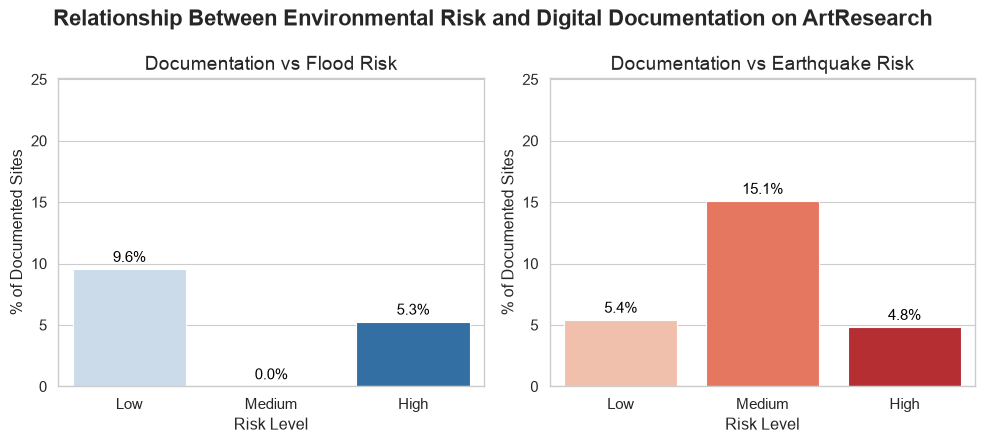

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

df = pd.read_csv("siti_con_rischio_e_digitalizzazione_CERTIFICATI.csv")

traduzione_rischio = {"Basso": "Low", "Medio": "Medium", "Elevato": "High"}
df['Rischio_Alluvione'] = df['Rischio_Alluvione'].replace(traduzione_rischio)
df['Rischio_Terremoto'] = df['Rischio_Terremoto'].replace(traduzione_rischio)

ordine_rischio = ["Low", "Medium", "High"]

def calcola_percentuali(dataframe, colonna_rischio):

    totali = dataframe.groupby(colonna_rischio).size()
   
    documentati = dataframe[dataframe['documentato'] == True].groupby(colonna_rischio).size()
    
    df_plot = pd.DataFrame({'Totale': totali, 'Documentati': documentati}).fillna(0)
    df_plot['Percentuale (%)'] = (df_plot['Documentati'] / df_plot['Totale']) * 100
    
    
    df_plot = df_plot.reindex(ordine_rischio).fillna(0)
    return df_plot.reset_index()

dati_alluvione = calcola_percentuali(df, 'Rischio_Alluvione')
dati_terremoto = calcola_percentuali(df, 'Rischio_Terremoto')

fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
fig.suptitle('Relationship Between Environmental Risk and Digital Documentation on ArtResearch', fontsize=16, fontweight='bold')

sns.barplot(data=dati_alluvione, x='Rischio_Alluvione', y='Percentuale (%)', 
            palette="Blues", ax=axes[0], order=ordine_rischio)
axes[0].set_title('Documentation vs Flood Risk', fontsize=14)
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('% of Documented Sites')
axes[0].set_ylim(0, max(dati_alluvione['Percentuale (%)'].max(), dati_terremoto['Percentuale (%)'].max()) + 10)

for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=11, color='black', xytext=(0, 8),
                     textcoords='offset points')

sns.barplot(data=dati_terremoto, x='Rischio_Terremoto', y='Percentuale (%)', 
            palette="Reds", ax=axes[1], order=ordine_rischio)
axes[1].set_title('Documentation vs Earthquake Risk', fontsize=14)
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('% of Documented Sites')
axes[1].set_ylim(0, max(dati_alluvione['Percentuale (%)'].max(), dati_terremoto['Percentuale (%)'].max()) + 10)

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=11, color='black', xytext=(0, 8),
                     textcoords='offset points')

plt.tight_layout()
plt.savefig("grafico_risultati_finali.png", dpi=300)
plt.show()

### Conclusions and Critical Discussion
The data analysis unequivocally shows no correlation between the level of environmental risk and the degree of digitization of the sites. The results bring to light a true paradox of conservation: digital mapping campaigns proceed entirely independently of preventive urgency, leaving the sites most exposed to natural disasters without secure digital documentation.

Furthermore, the project reveals a methodological issue that constitutes a fundamental finding: the necessity of using Exact String Matching due to the absence of a shared unique identifier and the fragmentation of cultural metadata has inevitably generated false negatives, excluding actual sites because of miscataloged strings. This empirically demonstrates that the true threat to the preventive preservation of cultural heritage is not only a lack of resources but the absence of semantic interoperability. Until institutions adopt shared standards and URIs based on Linked Open Data, the monitoring and preservation of historical memory will remain fragmented, exposing cultural heritage to the risk of irreversible physical and digital obliteration.


[CANVA_SLIDE](https://canva.link/x70i4al46523hg9)